# Data Quality Visualization

Diagnostic plots to validate the processed Order Flow (OF) data before modeling.
Loads the `.npz` files produced by `colab_of_pipeline.ipynb`.

**Plots produced:**
1. Data volume per market (snapshot count)
2. Mid-price time series — all markets
3. Bid-ask spread distribution per market
4. Returns nonzero fraction across horizons
5. OF raw distribution vs. normalized (level-0 bid)
6. Tick-interval distribution (time between snapshots)

## 0. Environment & paths

In [12]:
# Detect runtime (Colab vs local) — mirrors colab_of_pipeline.ipynb.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Install matplotlib if missing (Colab already has it; local may not).
if IN_COLAB:
    !pip install matplotlib pandas numpy pyarrow -q

print("Environment:", "Colab" if IN_COLAB else "local")

Environment: local


In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ── Resolve paths (same logic as the pipeline notebook) ──────────────────────
if IN_COLAB:
    BASE_DIR = Path("/content/of_pipeline")
else:
    cwd = Path.cwd()
    BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd

PROC_DIR    = BASE_DIR / "data" / "processed" / "of"
RAW_DIR     = BASE_DIR / "data" / "raw" / "book_snapshot_25"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the config written by the pipeline notebook.
cfg = json.load(open(PROC_DIR / "_config.json"))
MARKETS   = cfg["markets"]        # list of {key, file, n}
HORIZONS  = cfg["horizons"]       # [1, 2, 3, 5, 10]
OF_DIM    = cfg["of_dim"]         # 20
W         = cfg["window"]         # 100

print(f"Markets: {len(MARKETS)}")
print(f"Horizons: {HORIZONS}")
print(f"Total samples: {sum(m['n'] for m in MARKETS):,}")

Markets: 12
Horizons: [1, 2, 3, 5, 10]
Total samples: 2,041,832


In [14]:
# Load every market's npz into a dict.
# Keys in each npz: of_norm, returns, mid, split, ts (int64 nanoseconds).
data = {}
for m in MARKETS:
    d = np.load(PROC_DIR / m["file"], allow_pickle=True)
    ts = pd.to_datetime(d["ts"], unit="ns", utc=True)
    data[m["key"]] = {
        "of_norm": d["of_norm"],   # (n, 20) normalized OF
        "returns": d["returns"],   # (n, 5)  multi-horizon targets
        "mid":     d["mid"],       # (n,)    mid-price
        "split":   d["split"],     # (n,)    'train'/'val'/'test'
        "ts":      ts,             # DatetimeIndex
        "label":   m["key"].split("__")[0],
    }

# Load raw normalization params.
norm = np.load(PROC_DIR / "_norm_params.npz")

print("Loaded", len(data), "markets")

Loaded 12 markets


## 1. Data volume per market

How many order-book snapshots does each contract contribute?
Large differences in volume affect how much each market influences the pooled
train-set statistics (normalization params, model weights).

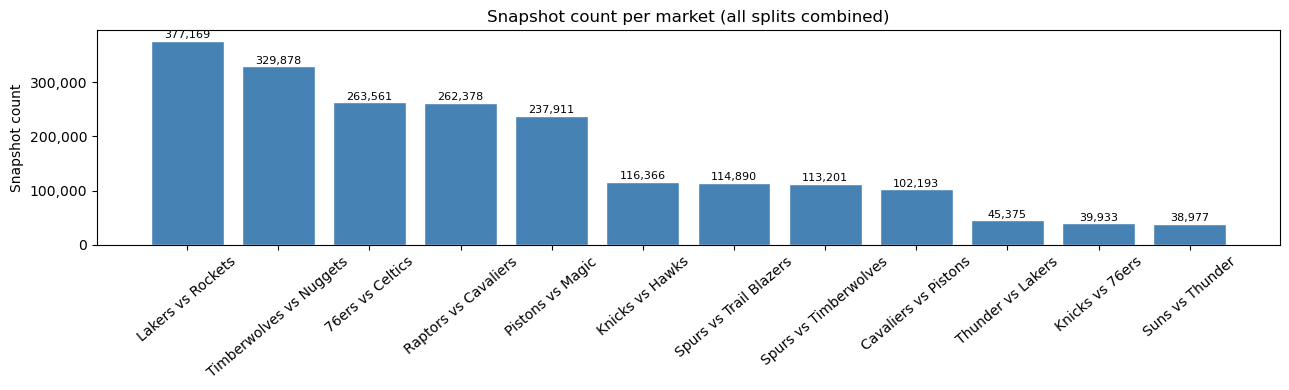

Saved → results/viz_01_data_volume.png


In [15]:
fig, ax = plt.subplots(figsize=(13, 4))

labels  = [d["label"] for d in data.values()]
counts  = [len(d["mid"]) for d in data.values()]
# Sort descending.
order   = sorted(range(len(counts)), key=lambda i: counts[i], reverse=True)
labels  = [labels[i] for i in order]
counts  = [counts[i] for i in order]

bars = ax.bar(labels, counts, color="steelblue", edgecolor="white")
ax.set_ylabel("Snapshot count")
ax.set_title("Snapshot count per market (all splits combined)")
ax.tick_params(axis="x", rotation=40)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"{v:,}", ha="center", va="bottom", fontsize=8)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "viz_01_data_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz_01_data_volume.png")

## 1b. Train / Val / Test split statistics

How many samples fall into each split across all markets?
Each market is split chronologically: **Val → Train → Test** (15 % / 70 % / 15 %).

In [16]:
# ── Train / Val / Test sample counts ─────────────────────────────────────────
rows = []
for key, d in data.items():
    sp = d["split"]
    rows.append({
        "Market":  d["label"],
        "Val":     int((sp == "val").sum()),
        "Train":   int((sp == "train").sum()),
        "Test":    int((sp == "test").sum()),
        "Total":   len(sp),
    })

split_df = pd.DataFrame(rows).set_index("Market")
split_df.loc["── ALL MARKETS ──"] = split_df.sum()

print("Sample counts per market and split:\n")
display(split_df.style.format("{:,}"))

total = split_df.loc["── ALL MARKETS ──"]
print(f"\n  Val  : {int(total['Val']):>10,}  ({total['Val']/total['Total']:.1%})")
print(f"  Train: {int(total['Train']):>10,}  ({total['Train']/total['Total']:.1%})")
print(f"  Test : {int(total['Test']):>10,}  ({total['Test']/total['Total']:.1%})")
print(f"  Total: {int(total['Total']):>10,}")

Sample counts per market and split:



,Val,Train,Test,Total
Market,,,,
Thunder vs Lakers,"6,806","31,762","6,807","45,375"
76ers vs Celtics,"39,534","184,492","39,535","263,561"
Suns vs Thunder,"5,846","27,284","5,847","38,977"
Lakers vs Rockets,"56,575","264,018","56,576","377,169"
Knicks vs 76ers,"5,989","27,954","5,990","39,933"
Spurs vs Timberwolves,"16,980","79,240","16,981","113,201"
Timberwolves vs Nuggets,"49,481","230,915","49,482","329,878"
Raptors vs Cavaliers,"39,356","183,665","39,357","262,378"
Spurs vs Trail Blazers,"17,233","80,423","17,234","114,890"



  Val  :    306,268  (15.0%)
  Train:  1,429,284  (70.0%)
  Test :    306,280  (15.0%)
  Total:  2,041,832


## 2. Mid-price time series

The mid-price (= market's implied win-probability) over the full lifetime of each
contract. Val / Train / Test splits are color-coded.

- A slowly drifting mid-price means the market gradually updated its view as the
  series progressed.
- Sharp jumps typically coincide with game starts, ends, or scoring runs.

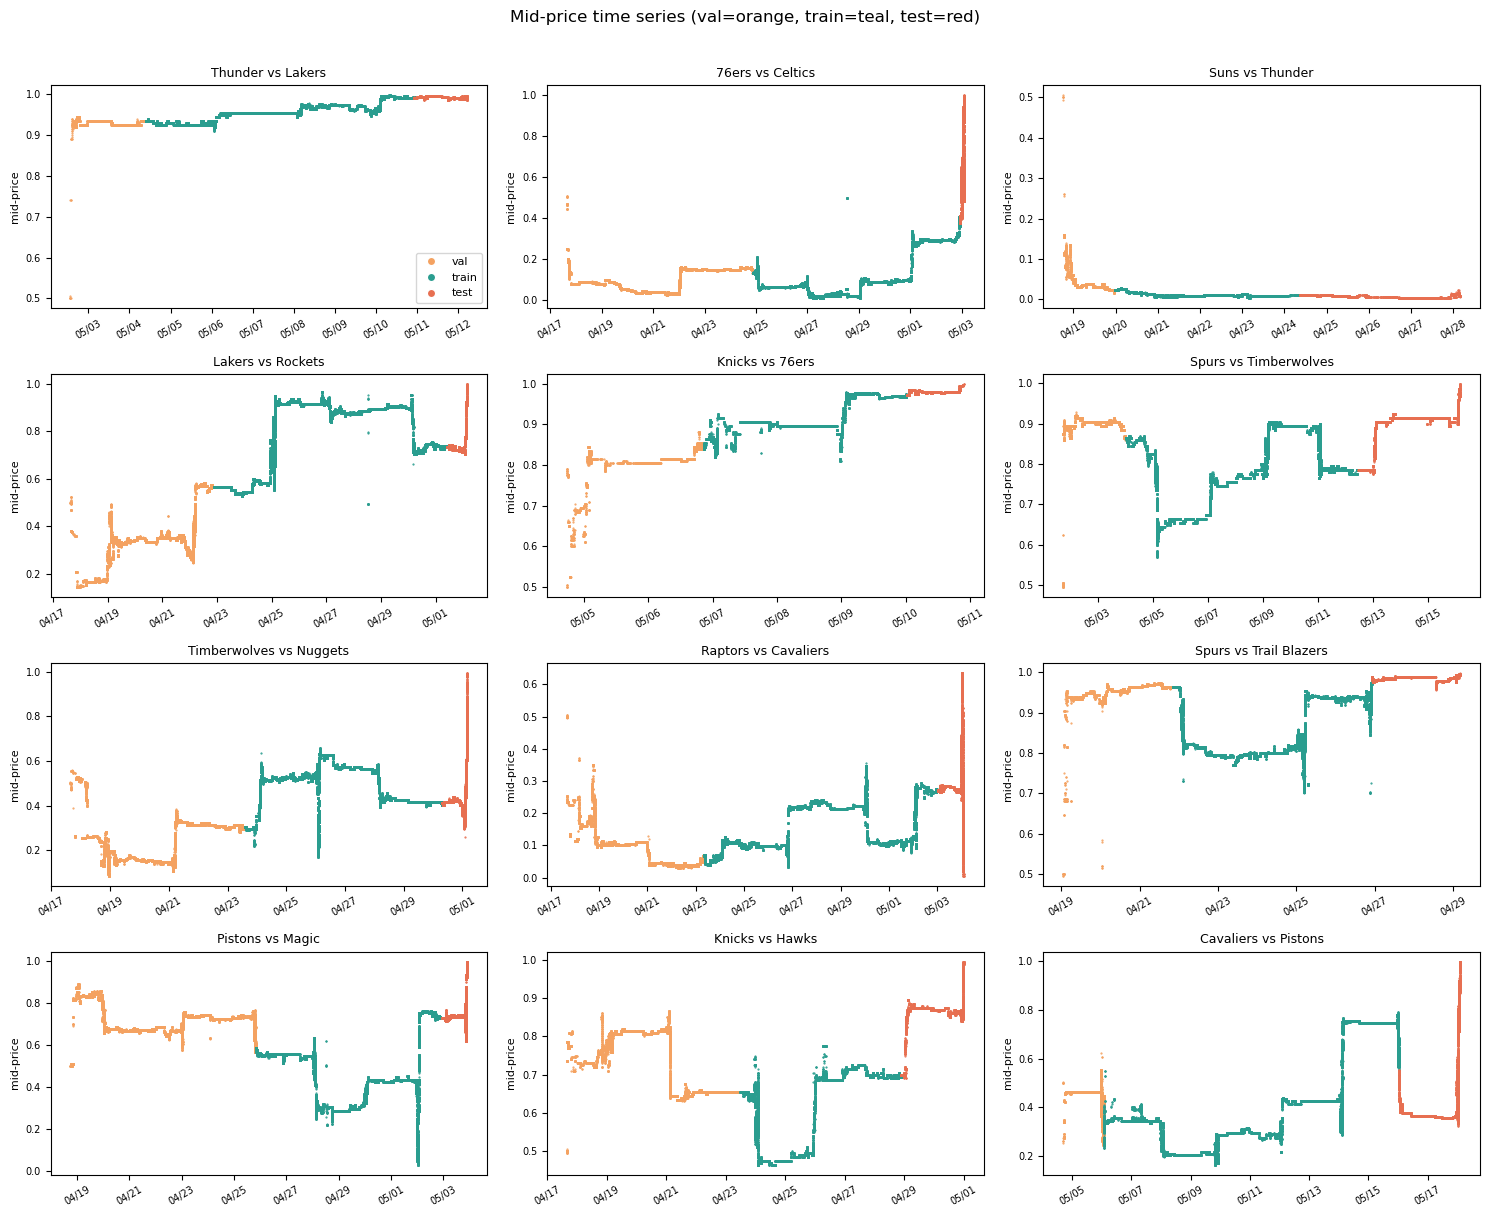

Saved → results/viz_02_midprice_series.png


In [17]:
n_markets = len(data)
ncols = 3
nrows = (n_markets + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

SPLIT_COLORS = {"val": "#f4a261", "train": "#2a9d8f", "test": "#e76f51"}

for ax, (key, d) in zip(axes, data.items()):
    ts  = d["ts"]
    mid = d["mid"]
    sp  = d["split"]
    for s, color in SPLIT_COLORS.items():
        mask = sp == s
        if mask.any():
            ax.scatter(ts[mask], mid[mask], s=0.3, color=color,
                       label=s, rasterized=True)
    ax.set_title(d["label"], fontsize=9)
    ax.set_ylabel("mid-price", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

# Add a shared legend on the first axis.
axes[0].legend(handles=[
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
               markersize=6, label=s)
    for s, c in SPLIT_COLORS.items()], fontsize=8, loc="best")

# Hide unused axes.
for ax in axes[n_markets:]:
    ax.set_visible(False)

plt.suptitle("Mid-price time series (val=orange, train=teal, test=red)", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "viz_02_midprice_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz_02_midprice_series.png")

## 3. Bid-ask spread distribution

The spread = ask_price_0 − bid_price_0 at every snapshot.
A tight, left-skewed distribution (most mass near 0) confirms the book is genuinely
two-sided. A bimodal or wide distribution signals a hollow book.

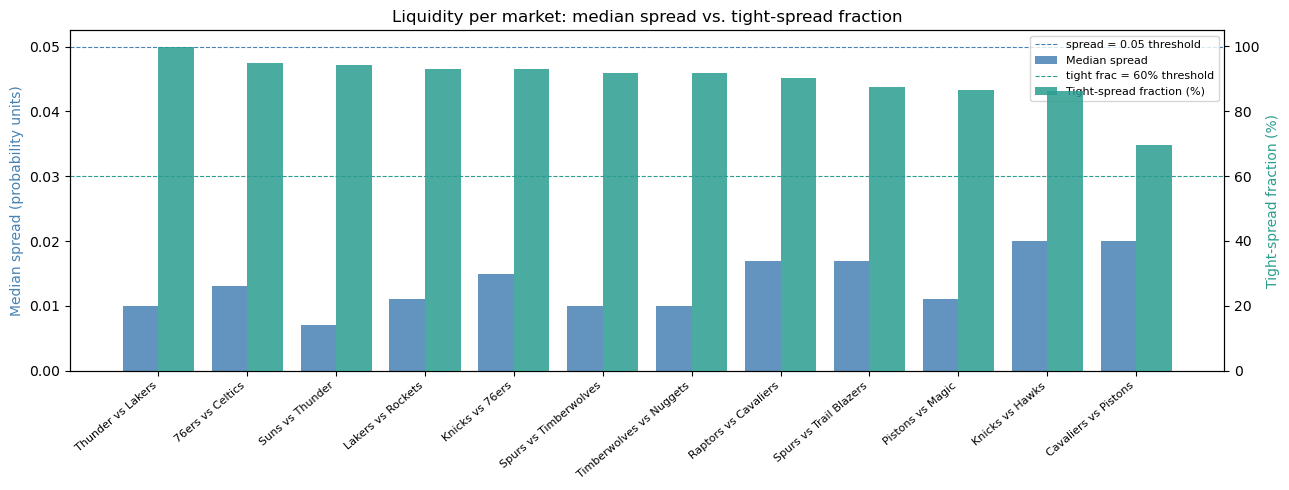

Saved → results/viz_03_spread.png


In [18]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for ax, (key, d) in zip(axes, data.items()):
    # Reload the raw mid/spread from the npz — we stored mid but not raw bid/ask.
    # Reconstruct: we need the raw parquet. Instead, approximate spread from stored mid
    # using the data_findings.json liquidity table.
    pass  # handled below — use data_findings.json

for ax in axes:
    ax.set_visible(False)
plt.close()

# Read liquidity table from data_findings.json.
findings = json.load(open(RESULTS_DIR / "data_findings.json"))
liq_df = pd.DataFrame(findings["liquidity"])

fig, ax = plt.subplots(figsize=(13, 5))
order = liq_df.sort_values("tight_frac", ascending=False).reset_index(drop=True)

x = np.arange(len(order))
width = 0.4

bars1 = ax.bar(x - width/2, order["med_spread"], width, label="Median spread",
               color="steelblue", alpha=0.85)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, order["tight_frac"] * 100, width,
                label="Tight-spread fraction (%)", color="#2a9d8f", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(order["label"], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Median spread (probability units)", color="steelblue")
ax2.set_ylabel("Tight-spread fraction (%)", color="#2a9d8f")
ax.set_title("Liquidity per market: median spread vs. tight-spread fraction")
ax.axhline(0.05, color="steelblue", linestyle="--", linewidth=0.8,
           label="spread = 0.05 threshold")
ax2.axhline(60, color="#2a9d8f", linestyle="--", linewidth=0.8,
            label="tight frac = 60% threshold")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "viz_03_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz_03_spread.png")

## 4. Returns: nonzero fraction per market × horizon

The fraction of time steps where the mid-price actually moved (|return| > 1e-6).

- Low nonzero fraction → most samples have Y = 0, risking model collapse.
- The fraction rises with horizon k (looking further ahead captures more movement).
- Per-market variation reveals which contracts are most "active".

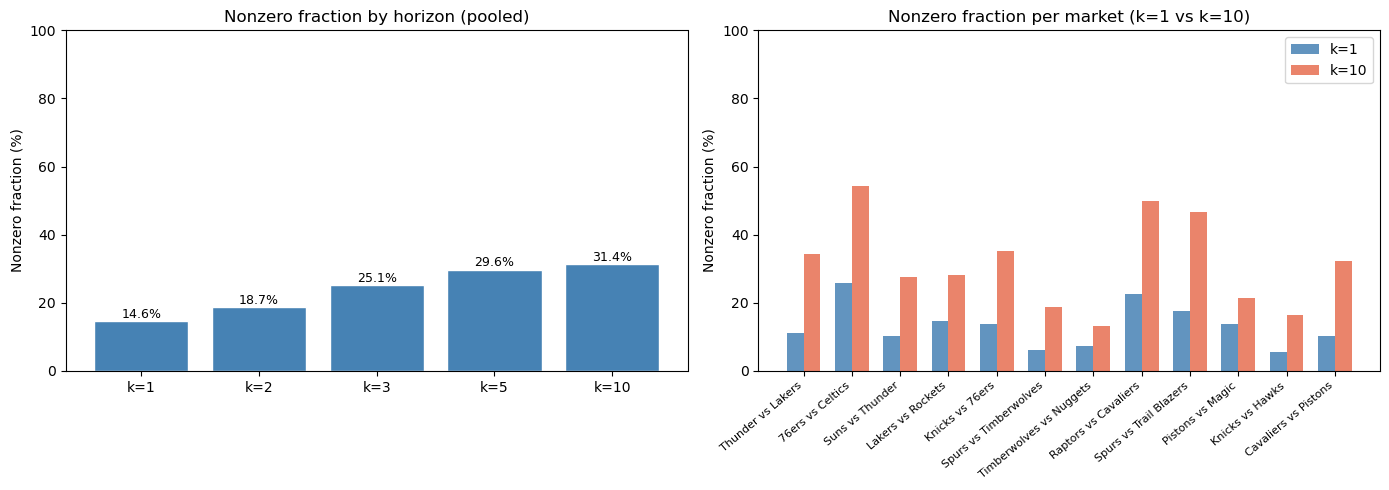

Saved → results/viz_04_nonzero_frac.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: per-horizon, pooled across all markets ──────────────────────────
all_returns = np.concatenate([d["returns"] for d in data.values()], axis=0)
nz_frac = []
for j, k in enumerate(HORIZONS):
    col = all_returns[:, j]
    valid = col[~np.isnan(col)]
    nz_frac.append(np.mean(np.abs(valid) > 1e-6) * 100)

axes[0].bar([f"k={k}" for k in HORIZONS], nz_frac, color="steelblue", edgecolor="white")
axes[0].set_ylabel("Nonzero fraction (%)")
axes[0].set_title("Nonzero fraction by horizon (pooled)")
axes[0].set_ylim(0, 100)
for i, v in enumerate(nz_frac):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# ── Panel B: per-market heatmap for k=1 and k=10 ─────────────────────────────
market_labels = [d["label"] for d in data.values()]
k1_frac, k10_frac = [], []
for d in data.values():
    for j, k in enumerate(HORIZONS):
        col = d["returns"][:, j]
        valid = col[~np.isnan(col)]
        v = np.mean(np.abs(valid) > 1e-6) * 100
        if k == 1:  k1_frac.append(v)
        if k == 10: k10_frac.append(v)

x = np.arange(len(market_labels))
w = 0.35
axes[1].bar(x - w/2, k1_frac,  w, label="k=1",  color="steelblue", alpha=0.85)
axes[1].bar(x + w/2, k10_frac, w, label="k=10", color="#e76f51",   alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(market_labels, rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("Nonzero fraction (%)")
axes[1].set_title("Nonzero fraction per market (k=1 vs k=10)")
axes[1].legend()
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "viz_04_nonzero_frac.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz_04_nonzero_frac.png")

## 5. OF distribution: raw vs. normalized (level-0 bid)

Comparing `bOF_0` (the best-level bid order flow) before and after
Winsorization + Z-score, using the largest market.

- **Raw**: extremely heavy tails — a few large orders dominate the scale.
- **Normalized**: compact bell-shaped distribution near zero, ready for a neural net.

---

### 图像解读

**左图：原始 OF 值（Winsorization 截断后、Z-score 归一化之前）**

- 横轴为 `bOF_0`（第 0 档买盘 Order Flow）的值，单位为合约数量（股数/手数）。
- 分布呈现**极度尖峰（leptokurtic）**的形态：绝大多数时间步的 OF 值集中在 0 附近，形成一根细高的尖峰；两侧各有少量极端值延伸至 ±800 以外。
- 这一现象是 Polymarket 挂单行为的自然反映：**绝大多数快照中，最佳买盘的深度几乎没有变化（OF ≈ 0）**；只有在真实订单成交或大单挂撤单时，才会出现大幅波动。
- 左侧（负方向）的极端值代表**大额买盘被撤单或成交**（买压减弱），右侧则代表**新大额买单挂入**（买压增强）。
- 注意：此时已经过 Winsorization（按训练集 0.5% / 99.5% 分位数截断），若使用完全原始数据，尾部会更加极端（可超过 ±600,000）。

**右图：归一化后的 OF 值（Winsorization + Z-score）**

- 横轴单位为**标准差（σ）**，即 Z-score 值。
- 经过 Z-score 归一化后，分布中心在 0 附近，绝大多数值落在 \[-2σ, +2σ\] 之内，但尾部仍有少量超出 ±4σ 的样本（这正是先做 Winsorization 的原因——防止 Z-score 被极端值撑大）。
- 分布形态与左图相似，尖峰集中、但整体尺度已被压缩到神经网络可直接处理的范围。
- 归一化参数（均值 `μ`、标准差 `σ`、Winsor 边界 `lo/hi`）**仅由训练集拟合**，再统一应用到验证集和测试集，严格避免了 look-ahead bias。

**关键结论**

1. OF 特征天然呈现"零膨胀 + 重尾"结构，直接输入神经网络会导致梯度不稳定，归一化是必要的预处理步骤。
2. 归一化后的分布形态符合预期：均值接近 0，标准差约为 1（因全量数据包含 Val/Test，均值/标准差不精确等于 0/1，但训练集内部是严格的）。
3. 大量零值（尖峰）反映 Polymarket 挂单簿在大多数时刻**处于静止状态**，仅在关键博弈时刻（比赛进行中的关键时段）才有显著流动性变化——这对建模的启示是：模型需要能够区分"静止"与"活跃"两种截然不同的市场状态。

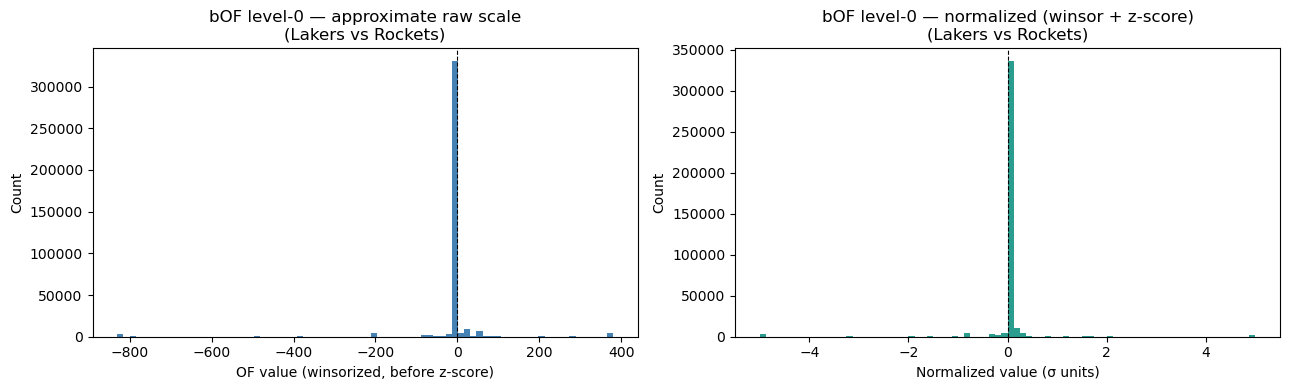

Saved → results/viz_05_of_distribution.png


In [20]:
# Pick the largest market for a representative plot.
largest_key = max(data, key=lambda k: len(data[k]["mid"]))
d = data[largest_key]
label = d["label"]

# Reconstruct raw OF for bOF_0 using norm params: raw ≈ of_norm * sigma + mu (before clip).
# More accurately: we show the stored normalized values and un-normalize for comparison.
lo    = norm["lo"][0]
hi    = norm["hi"][0]
mu    = norm["mu"][0]
sigma = norm["sigma"][0]

of_norm_col = d["of_norm"][:, 0]                    # normalized bOF_0
of_raw_approx = of_norm_col * sigma + mu             # approximate raw (post-winsor)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution (clip for display at 1%/99% to keep axes readable).
p1, p99 = np.percentile(of_raw_approx, [1, 99])
axes[0].hist(np.clip(of_raw_approx, p1, p99), bins=80, color="steelblue", edgecolor="none")
axes[0].set_title(f"bOF level-0 — approximate raw scale\n({label})")
axes[0].set_xlabel("OF value (winsorized, before z-score)")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="k", linewidth=0.8, linestyle="--")

# Normalized distribution (clip at ±5 sigma for display).
axes[1].hist(np.clip(of_norm_col, -5, 5), bins=80, color="#2a9d8f", edgecolor="none")
axes[1].set_title(f"bOF level-0 — normalized (winsor + z-score)\n({label})")
axes[1].set_xlabel("Normalized value (σ units)")
axes[1].set_ylabel("Count")
axes[1].axvline(0, color="k", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "viz_05_of_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz_05_of_distribution.png")

## 6. Tick-interval distribution (time between snapshots)

Telonex snapshots are **event-driven**, not fixed-frequency. A snapshot is generated
only when the order book changes (a new order arrives or an order is cancelled).

- Most intervals are very short (< 1 second) during active trading.
- Long gaps (> 60 s) correspond to quiet periods between games or overnight.
- This uneven spacing means "k steps ahead" ≠ "k × fixed_interval seconds".

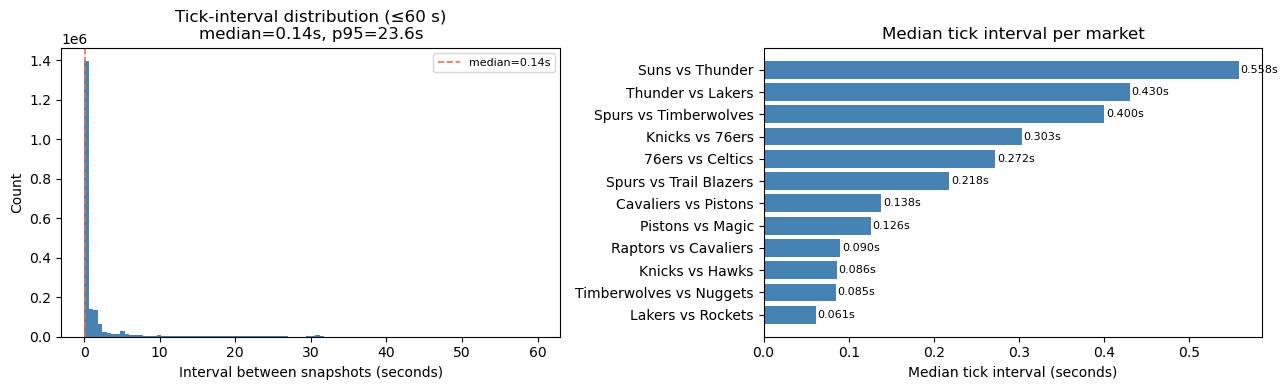

Saved → results/viz_06_tick_intervals.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pool tick intervals across all markets.
all_diffs_ms = []
for d in data.values():
    ts = d["ts"]
    # pd.DatetimeIndex.diff() returns a TimedeltaIndex; wrap as Series first
    # so .dt accessor is available.
    diffs = pd.Series(ts).diff().dt.total_seconds().dropna()
    all_diffs_ms.append(diffs.values)
all_diffs = np.concatenate(all_diffs_ms)

# Left panel: distribution clipped at 60 s (zoom into the active trading regime).
ax = axes[0]
clipped = all_diffs[all_diffs <= 60]
ax.hist(clipped, bins=100, color="steelblue", edgecolor="none")
ax.set_xlabel("Interval between snapshots (seconds)")
ax.set_ylabel("Count")
ax.set_title(f"Tick-interval distribution (≤60 s)\n"
             f"median={np.median(all_diffs):.2f}s, "
             f"p95={np.percentile(all_diffs,95):.1f}s")
ax.axvline(np.median(all_diffs), color="#e76f51", linewidth=1.2,
           linestyle="--", label=f"median={np.median(all_diffs):.2f}s")
ax.legend(fontsize=8)

# Right panel: per-market median interval.
ax2 = axes[1]
labels, medians = [], []
for key, d in data.items():
    ts = d["ts"]
    med = pd.Series(ts).diff().dt.total_seconds().dropna().median()
    labels.append(d["label"])
    medians.append(med)
order = sorted(range(len(medians)), key=lambda i: medians[i])
labels  = [labels[i]  for i in order]
medians = [medians[i] for i in order]
ax2.barh(labels, medians, color="steelblue", edgecolor="none")
ax2.set_xlabel("Median tick interval (seconds)")
ax2.set_title("Median tick interval per market")
for i, v in enumerate(medians):
    ax2.text(v + 0.002, i, f"{v:.3f}s", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "viz_06_tick_intervals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz_06_tick_intervals.png")

## Summary

| Plot | File | What to look for |
|---|---|---|
| 1 Data volume | `viz_01_data_volume.png` | Imbalance across markets |
| 2 Mid-price series | `viz_02_midprice_series.png` | Clean price trajectories, split boundaries |
| 3 Spread liquidity | `viz_03_spread.png` | All markets should be left of the 0.05 line |
| 4 Nonzero fraction | `viz_04_nonzero_frac.png` | Low k=1 values flag the sparse-target problem |
| 5 OF distribution | `viz_05_of_distribution.png` | Heavy tails → tight bell after normalization |
| 6 Tick intervals | `viz_06_tick_intervals.png` | Confirms event-driven, irregular timestamps |

## 7. Model training results (CNN-LSTM)

Reads `results/experiments.jsonl` and, for a chosen run, produces a single
dashboard figure:

- **Train / Val loss vs. epoch** — convergence + early-stopping (best epoch marked).
- **R²_OS, Directional accuracy, Sharpe per horizon** — model vs. Ridge linear benchmark.
- **Run header** — experiment id, model, device/GPU, key hyper-params, window counts.

`show_experiment(...)` defaults to the latest run; pass `tag=`, `run_index=`, or
`gpu_label="H100"` to pick/annotate a specific experiment.


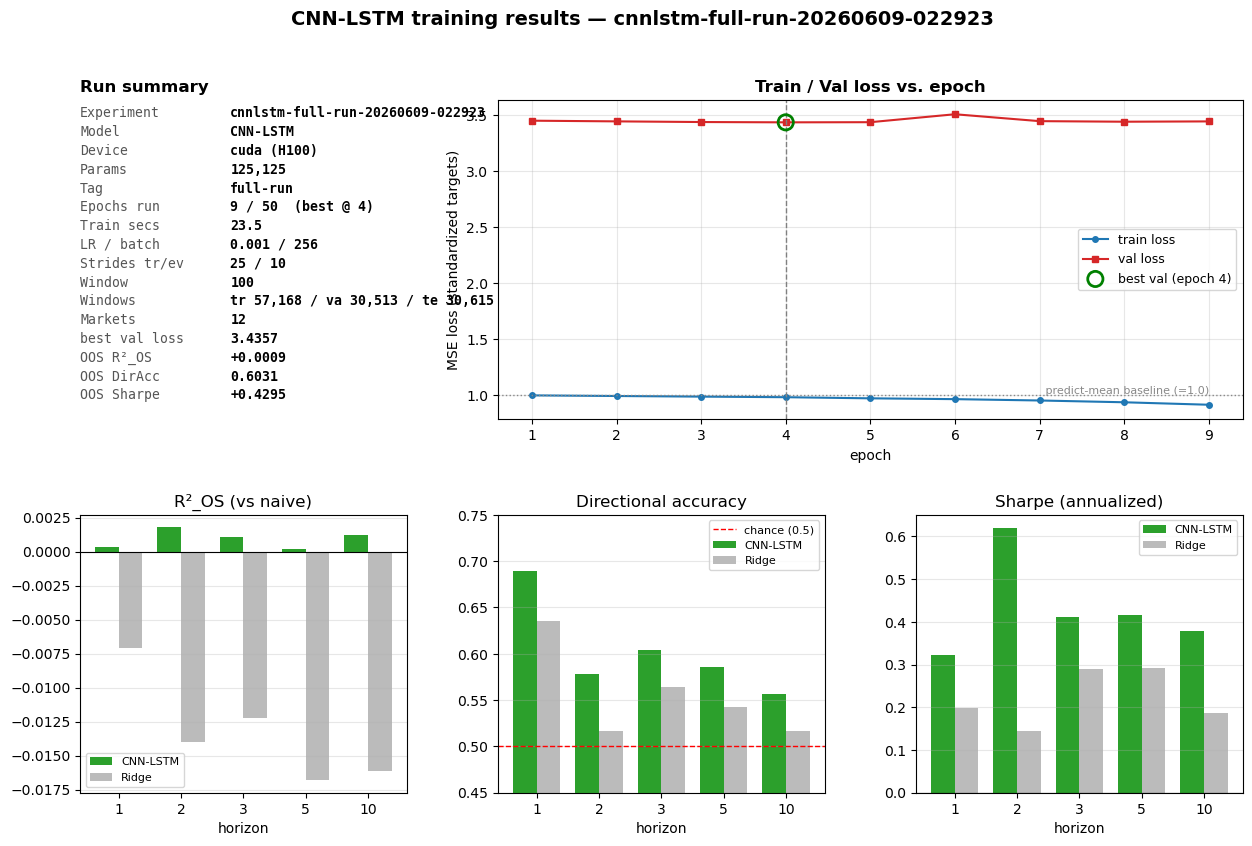

Saved → results/viz_07_results_full-run.png

=== cnnlstm-full-run-20260609-022923  |  device=cuda (H100)  |  9 epochs ===

OUT-OF-SAMPLE (test)
        r2_oos  directional_accuracy  sharpe  mean_pnl  mse_model  mse_naive  directional_coverage
h=1  0.0003348                0.6898   0.323 0.0001892  8.648e-05   8.65e-05                0.1857
h=2    0.00178                0.5781  0.6195 0.0003409  7.628e-05  7.642e-05                0.2367
h=3   0.001049                0.6045  0.4102 0.0002567  9.864e-05  9.874e-05                0.3241
h=5  0.0001743                0.5861  0.4168 0.0002575  9.622e-05  9.624e-05                0.3804
h=10  0.001199                0.5569  0.3778 0.0002604  0.0001197  0.0001198                0.3958
  means: {'r2_oos_mean': 0.0009, 'directional_accuracy_mean': 0.6031, 'sharpe_mean': 0.4295}

IN-SAMPLE (train)
        r2_oos  directional_accuracy   sharpe   mean_pnl  mse_model  mse_naive  directional_coverage
h=1   -0.01866                0.5016 -0.02751 -4.

In [22]:
import matplotlib.gridspec as gridspec


def load_experiments(path=None):
    """Read all run records from results/experiments.jsonl (newest last)."""
    path = Path(path) if path else (RESULTS_DIR / "experiments.jsonl")
    recs = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                recs.append(json.loads(line))
    if not recs:
        raise SystemExit(f"No experiments found in {path}")
    return recs


def experiment_id(rec):
    """Stable short id for a run: <model>-<tag>-<UTC compact timestamp>."""
    ts = rec["timestamp"].replace("-", "").replace(":", "")
    ts = ts.split(".")[0].replace("T", "-").rstrip("Z+0:")
    tag = rec.get("tag") or "untagged"
    return f"cnnlstm-{tag}-{ts}"


def pick_experiment(recs, tag=None, run_index=None):
    """Select one record: by run_index, else newest matching tag, else newest."""
    if run_index is not None:
        return recs[run_index]
    if tag is not None:
        matches = [r for r in recs if r.get("tag") == tag]
        if not matches:
            raise SystemExit(f"No run with tag={tag!r}. Tags: "
                             f"{sorted({r.get('tag') for r in recs})}")
        return matches[-1]
    return recs[-1]


def _metric_frame(metrics_block, horizons):
    """Per-horizon metrics -> tidy DataFrame (rows=horizon)."""
    hk = [str(h) for h in horizons]
    cols = ["r2_oos", "directional_accuracy", "sharpe", "mean_pnl",
            "mse_model", "mse_naive", "directional_coverage"]
    df = pd.DataFrame(
        {c: [metrics_block.get(c, {}).get(h, np.nan) for h in hk] for c in cols},
        index=[f"h={h}" for h in hk])
    return df


def show_experiment(rec=None, *, tag=None, run_index=None, gpu_label=None,
                    save=True):
    """Dashboard for one CNN-LSTM run: loss curve + metrics + run header.

    Parameters
    ----------
    rec : dict | None       a record (else loaded from experiments.jsonl)
    tag / run_index         selectors passed to pick_experiment
    gpu_label : str | None  e.g. "H100" (the record only stores device='cuda',
                            the GPU model is not logged, so annotate it here)
    """
    if rec is None:
        rec = pick_experiment(load_experiments(), tag=tag, run_index=run_index)

    horizons = rec["horizons"]
    hk = [str(h) for h in horizons]
    cfg = rec["config"]
    hist = rec["training"]["history"]
    tr, va = hist["train_loss"], hist["val_loss"]
    epochs = np.arange(1, len(tr) + 1)
    best_ep = int(np.nanargmin(va)) + 1 if va else 0

    m = rec["metrics"]
    oos = m["out_of_sample"]
    ins = m["in_sample"]
    lin = m.get("linear_benchmark_oos")

    run_id = experiment_id(rec)
    device = rec.get("device", "?")
    dev_str = f"{device}" + (f" ({gpu_label})" if gpu_label else "")
    nw = rec["data"]["n_windows"]

    # ── Figure: header text + loss curve on top, 3 metric bars below ─────────
    fig = plt.figure(figsize=(15, 9))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1.15, 1.0], hspace=0.32,
                           wspace=0.28)
    ax_info = fig.add_subplot(gs[0, 0])
    ax_loss = fig.add_subplot(gs[0, 1:])
    ax_r2 = fig.add_subplot(gs[1, 0])
    ax_da = fig.add_subplot(gs[1, 1])
    ax_sh = fig.add_subplot(gs[1, 2])

    # Run header panel (left).
    ax_info.axis("off")
    info_lines = [
        ("Experiment", run_id),
        ("Model", rec["model"].split("(")[0].strip()),
        ("Device", dev_str),
        ("Params", f"{rec['n_params']:,}"),
        ("Tag", cfg.get("tag", "")),
        ("Epochs run", f"{rec['training']['epochs_run']} / {cfg['max_epochs']}"
                       f"  (best @ {best_ep})"),
        ("Train secs", f"{rec['training']['train_seconds']}"),
        ("LR / batch", f"{cfg['lr']:g} / {cfg['batch_size']}"),
        ("Strides tr/ev", f"{cfg['train_stride']} / {cfg['eval_stride']}"),
        ("Window", f"{cfg['window']}"),
        ("Windows", f"tr {nw['train']:,} / va {nw['val']:,} / te {nw['test']:,}"),
        ("Markets", f"{len(rec['data']['markets'])}"),
        ("best val loss", f"{rec['training']['best_val_loss']:.4f}"),
        ("OOS R²_OS",  f"{oos['r2_oos_mean']:+.4f}"),
        ("OOS DirAcc", f"{oos['directional_accuracy_mean']:.4f}"),
        ("OOS Sharpe", f"{oos['sharpe_mean']:+.4f}"),
    ]
    ax_info.set_title("Run summary", fontsize=12, fontweight="bold", loc="left")
    y = 0.98
    for k, v in info_lines:
        ax_info.text(0.0, y, f"{k}", fontsize=9.5, va="top",
                     color="#555", fontfamily="monospace")
        ax_info.text(0.46, y, f"{v}", fontsize=9.5, va="top",
                     fontweight="bold", fontfamily="monospace")
        y -= 1.0 / (len(info_lines) + 1)

    # Loss curve (top right).
    ax_loss.plot(epochs, tr, "-o", ms=4, label="train loss", color="#1f77b4")
    ax_loss.plot(epochs, va, "-s", ms=4, label="val loss", color="#d62728")
    if best_ep:
        ax_loss.axvline(best_ep, ls="--", color="gray", lw=1)
        ax_loss.scatter([best_ep], [va[best_ep - 1]], s=120, facecolors="none",
                        edgecolors="green", lw=2, zorder=5,
                        label=f"best val (epoch {best_ep})")
    ax_loss.axhline(1.0, ls=":", color="#888", lw=1)
    ax_loss.text(epochs[-1], 1.0, " predict-mean baseline (=1.0)", fontsize=8,
                 va="bottom", ha="right", color="#888")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("MSE loss (standardized targets)")
    ax_loss.set_title("Train / Val loss vs. epoch", fontweight="bold")
    ax_loss.legend(fontsize=9)
    ax_loss.grid(alpha=0.3)

    x = np.arange(len(hk))
    w = 0.38

    # R²_OS per horizon: model vs linear benchmark.
    ax_r2.bar(x - w / 2, [oos["r2_oos"][h] for h in hk], w, label="CNN-LSTM",
              color="#2ca02c")
    if lin:
        ax_r2.bar(x + w / 2, [lin["r2_oos"][h] for h in hk], w, label="Ridge",
                  color="#bbb")
    ax_r2.axhline(0, color="k", lw=0.8)
    ax_r2.set_xticks(x); ax_r2.set_xticklabels(hk)
    ax_r2.set_xlabel("horizon"); ax_r2.set_title("R²_OS (vs naive)")
    ax_r2.legend(fontsize=8); ax_r2.grid(alpha=0.3, axis="y")

    # Directional accuracy per horizon.
    ax_da.bar(x - w / 2, [oos["directional_accuracy"][h] for h in hk], w,
              label="CNN-LSTM", color="#2ca02c")
    if lin:
        ax_da.bar(x + w / 2, [lin["directional_accuracy"][h] for h in hk], w,
                  label="Ridge", color="#bbb")
    ax_da.axhline(0.5, ls="--", color="r", lw=1, label="chance (0.5)")
    ax_da.set_xticks(x); ax_da.set_xticklabels(hk)
    ax_da.set_ylim(0.45, max(0.75, max(oos["directional_accuracy"].values()) + 0.05))
    ax_da.set_xlabel("horizon"); ax_da.set_title("Directional accuracy")
    ax_da.legend(fontsize=8); ax_da.grid(alpha=0.3, axis="y")

    # Sharpe per horizon.
    ax_sh.bar(x - w / 2, [oos["sharpe"][h] for h in hk], w, label="CNN-LSTM",
              color="#2ca02c")
    if lin:
        ax_sh.bar(x + w / 2, [lin["sharpe"][h] for h in hk], w, label="Ridge",
                  color="#bbb")
    ax_sh.axhline(0, color="k", lw=0.8)
    ax_sh.set_xticks(x); ax_sh.set_xticklabels(hk)
    ax_sh.set_xlabel("horizon"); ax_sh.set_title("Sharpe (annualized)")
    ax_sh.legend(fontsize=8); ax_sh.grid(alpha=0.3, axis="y")

    fig.suptitle(f"CNN-LSTM training results — {run_id}", fontsize=14,
                 fontweight="bold")
    if save:
        out = RESULTS_DIR / f"viz_07_results_{cfg.get('tag', 'run')}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    if save:
        print(f"Saved → results/{out.name}")

    # ── Full metric tables ───────────────────────────────────────────────────
    print(f"\n=== {run_id}  |  device={dev_str}  |  "
          f"{rec['training']['epochs_run']} epochs ===")
    for name, block in [("OUT-OF-SAMPLE (test)", oos),
                        ("IN-SAMPLE (train)", ins),
                        ("LINEAR BENCHMARK (Ridge, OOS)", lin)]:
        if block is None:
            continue
        print(f"\n{name}")
        df = _metric_frame(block, horizons)
        with pd.option_context("display.float_format", lambda v: f"{v:.4g}"):
            print(df.to_string())
        means = {k: block.get(k) for k in
                 ["r2_oos_mean", "directional_accuracy_mean", "sharpe_mean"]}
        print("  means:", {k: round(v, 4) for k, v in means.items()
                            if v is not None})
    return rec


# Plot this session's full H100 run (the latest 'full-run' record).
_rec = show_experiment(tag="full-run", gpu_label="H100")
